# Waterfilling Levels

In [104]:
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import cvxpy as cp

# importlib.reload(food_bank_functions)

In [142]:
def generate_cvxpy_solve(num_types, num_resources):
    x = cp.Variable(shape=(num_types,num_resources))

    sizes = cp.Parameter(num_types, nonneg=True)
    weights = cp.Parameter((num_types, num_resources), nonneg=True)
    budget = cp.Parameter(num_resources, nonneg=True)


    objective = cp.Maximize(cp.log(cp.sum(cp.multiply(x, weights), axis=1)) @ sizes)


    constraints = []
    constraints += [0 <= x]
    for i in range(num_resources):
        constraints += [x[:, i] @ sizes <= budget[i]]
    constraints += [x @ sizes <= budget]

    prob = cp.Problem(objective, constraints)
    
    def solver(true_sizes, true_weights, true_budget):
        sizes.value = true_sizes
        weights.value = true_weights
        budget.value = true_budget
        
        prob.solve()
        
        return prob.value, x.value
    
    return prob, solver

### Test

In [148]:
prob, solver = generate_cvxpy_solve(2, 2)

solver(np.asarray([1., 1.]), np.asarray([[1,1],[1,1]]), np.asarray([1,1]))

(1.0641477147538018e-09, array([[0.50000001, 0.49999999],
        [0.49999999, 0.50000001]]))

### Plot Sensitivity

Calculating difference in allocations for: 0.05
Sizes: ([1.0, 1.0], [0.95, 0.95], [1.05, 1.05])
Solutions: (array([[1., 1.],
       [1., 1.]]), array([[1.05262895, 1.0526342 ],
       [1.0526342 , 1.05262895]]), array([[0.9523827, 0.9523792],
       [0.9523792, 0.9523827]]))
Testing Budget Constraint: 
[ True  True]
Testing Monotonicity:
[[ True  True]
 [ True  True]]
[[ True  True]
 [ True  True]]
Calculating difference in allocations for: 0.1
Sizes: ([1.0, 1.0], [0.9, 0.9], [1.1, 1.1])
Solutions: (array([[1., 1.],
       [1., 1.]]), array([[1.11110715, 1.11111506],
       [1.11111506, 1.11110715]]), array([[0.9090936 , 0.90908821],
       [0.90908821, 0.9090936 ]]))
Testing Budget Constraint: 
[ True  True]
Testing Monotonicity:
[[ True  True]
 [ True  True]]
[[ True  True]
 [ True  True]]
Calculating difference in allocations for: 0.15000000000000002
Sizes: ([1.0, 1.0], [0.85, 0.85], [1.15, 1.15])
Solutions: (array([[1., 1.],
       [1., 1.]]), array([[1.17647061, 1.17647057],
     

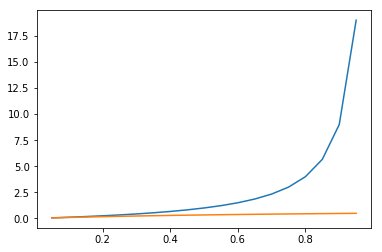

In [153]:
eps = 0.05

delta_list = np.arange(eps, 1, eps)
y1 = np.zeros(len(delta_list))
y2 = np.zeros(len(delta_list))

prob, solver = generate_cvxpy_solve(2, 2)
true_weights = np.asarray([[1., 1.],[1., 1.]])
true_budget = [2., 2.]


index = 0
for delta in delta_list:
    print('Calculating difference in allocations for: ' + str(delta))
    sizes_1 = [1., 1.]
    sizes_2 = [1-delta, 1-delta]
    sizes_3 = [1+delta, 1+delta]
    
    print('Sizes: ' + str((sizes_1, sizes_2, sizes_3)))
          
    _, x_1 = solver(sizes, true_weights, true_budget)
    _, x_2 = solver(sizes_2, true_weights, true_budget)
    _, x_3 = solver(sizes_3, true_weights, true_budget)
    
    print('Solutions: ' + str((x_1, x_2, x_3)))
    
    print('Testing Budget Constraint: ')
    print(sizes_1 @ x_1 <= true_budget)
    
    print('Testing Monotonicity:')
    print(x_1 <= x_2)
    print(x_1 >= x_3)
    y1[index] = np.max(np.abs(x_1 - x_2))
    y2[index] = np.max(np.abs(x_1 - x_3))
    index += 1
    
print(delta_list, y1, y2)
plt.plot(delta_list, y1)
plt.plot(delta_list, y2)